# Tutorial 3: Image Classification with CNN (CIFAR-10)


## 1. Setup — Install & Import Libraries

In [1]:
!pip install tensorflow scikit-learn matplotlib seaborn --quiet

In [3]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Load & Explore CIFAR-10

CIFAR-10 consists of 60,000 colour images (32×32 px, 3 channels) across 10 classes, split into 50,000 training and 10,000 test samples.

In [5]:
(img_train, lbl_train), (img_test, lbl_test) = datasets.cifar10.load_data()

print("Train images:", img_train.shape)
print("Test images :", img_test.shape)

Train images: (50000, 32, 32, 3)
Test images : (10000, 32, 32, 3)


In [7]:
lbl_train = lbl_train.reshape(-1,)
lbl_test  = lbl_test.reshape(-1,)

label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Sample labels:", lbl_train[:5])
print("Class names  :", [label_names[i] for i in lbl_train[:5]])

Sample labels: [6 9 9 4 1]
Class names  : ['frog', 'truck', 'truck', 'deer', 'automobile']


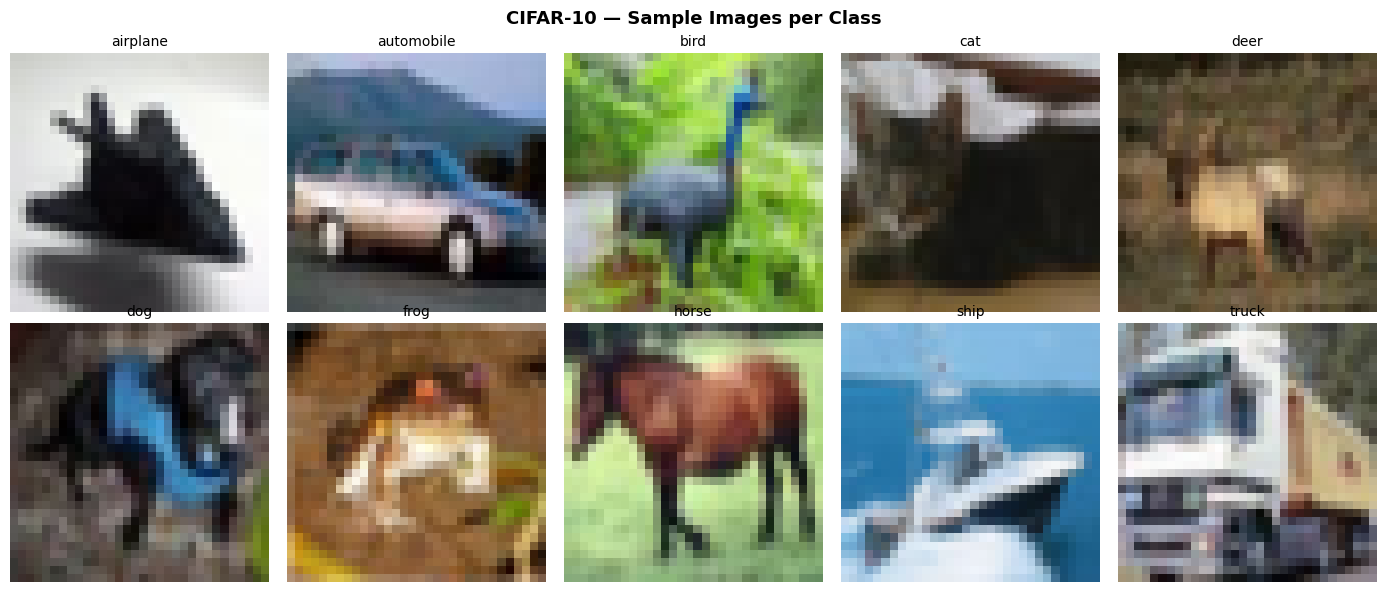

In [9]:
# Plot one sample per class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('CIFAR-10 — Sample Images per Class', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    sample_idx = np.where(lbl_train == i)[0][0]
    ax.imshow(img_train[sample_idx])
    ax.set_title(label_names[i], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Preprocessing

Pixel values are normalised from `[0, 255]` → `[0.0, 1.0]` to stabilise and speed up training.

In [12]:
img_train = img_train / 255.0
img_test  = img_test  / 255.0
print("Pixel range — min:", img_train.min(), " max:", img_train.max())

Pixel range — min: 0.0  max: 1.0


## 4. Baseline Model — ANN

A plain fully-connected network with no convolutional layers, used as a performance baseline.

| Layer | Details |
|---|---|
| Flatten | 32×32×3 → 3072 |
| Dense | 3000 neurons, ReLU |
| Dense | 1000 neurons, ReLU |
| Dense | 10 neurons, Softmax |

**Optimizer:** SGD &nbsp;|&nbsp; **Epochs:** 5

In [14]:
baseline_ann = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10,   activation='softmax')
], name='Baseline_ANN')

baseline_ann.compile(optimizer='SGD',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

baseline_ann.summary()

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Baseline_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3000)           │     9,219,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │     3,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,230,010 (46.65 MB)

 Trainable params: 12,230,010 (46.65 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
ann_history = baseline_ann.fit(img_train, lbl_train, epochs=5,
                               validation_data=(img_test, lbl_test), verbose=1)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.3558 - loss: 1.8089 - val_accuracy: 0.3996 - val_loss: 1.6919
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 30ms/step - accuracy: 0.4259 - loss: 1.6222 - val_accuracy: 0.3641 - val_loss: 1.7895
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 28ms/step - accuracy: 0.4581 - loss: 1.5403 - val_accuracy: 0.4664 - val_loss: 1.5223
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.4770 - loss: 1.4806 - val_accuracy: 0.4523 - val_loss: 1.5626
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.4954 - loss: 1.4314 - val_accuracy: 0.4399 - val_loss: 1.5466


In [17]:
ann_loss, ann_acc = baseline_ann.evaluate(img_test, lbl_test, verbose=0)
print(f"Baseline ANN — Accuracy: {ann_acc*100:.2f}% | Loss: {ann_loss:.4f}")

Baseline ANN — Accuracy: 43.99% | Loss: 1.5466


In [18]:
ann_preds   = baseline_ann.predict(img_test)
ann_pred_cls = [np.argmax(p) for p in ann_preds]

print("=== Baseline ANN — Classification Report ===")
print(classification_report(lbl_test, ann_pred_cls, target_names=label_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
=== Baseline ANN — Classification Report ===
              precision    recall  f1-score   support

    airplane       0.65      0.38      0.48      1000
  automobile       0.69      0.50      0.58      1000
        bird       0.38      0.25      0.30      1000
         cat       0.36      0.37      0.36      1000
        deer       0.24      0.75      0.37      1000
         dog       0.53      0.20      0.29      1000
        frog       0.52      0.50      0.51      1000
       horse       0.63      0.38      0.48      1000
        ship       0.47      0.73      0.57      1000
       truck       0.71      0.34      0.46      1000

    accuracy                           0.44     10000
   macro avg       0.52      0.44      0.44     10000
weighted avg       0.52      0.44      0.44     10000



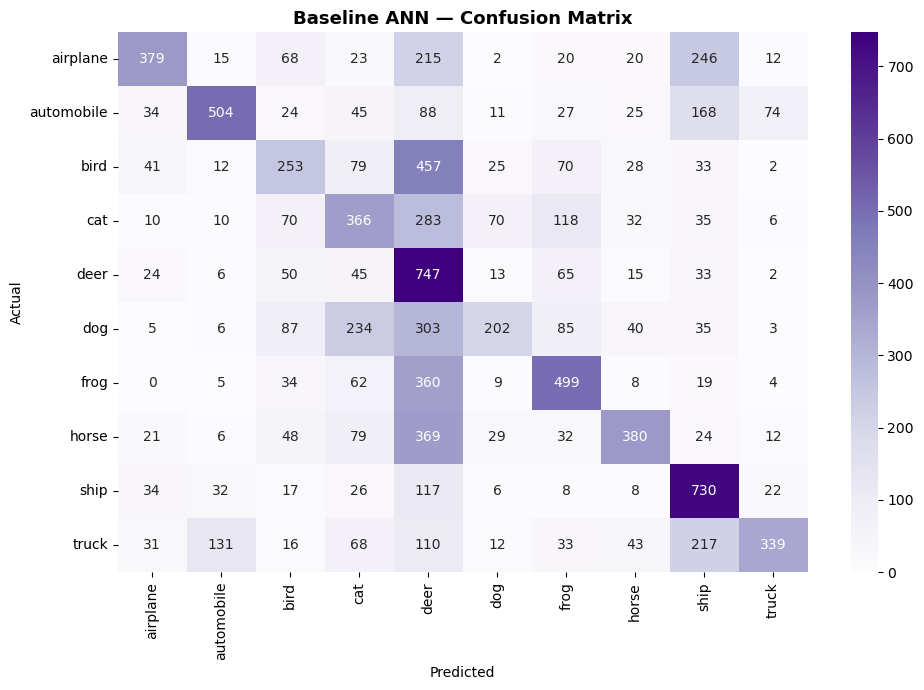

In [22]:
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(lbl_test, ann_pred_cls),
            annot=True, fmt='d', cmap='Purples',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Baseline ANN — Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 5. Evaluation Metrics

| Metric | Formula | What it tells us |
|---|---|---|
| **Accuracy** | Correct / Total | Overall correct predictions |
| **Precision** | TP / (TP + FP) | How reliable positive predictions are |
| **Recall** | TP / (TP + FN) | How many actual positives were caught |
| **F1-Score** | 2×P×R / (P+R) | Balance between precision and recall |
| **Loss** | Cross-entropy | Lower = better probability calibration |

## 6. Original CNN

Adds convolutional layers to extract spatial features (edges, textures, shapes) before classification.



In [24]:
original_cnn = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='Original_CNN')

original_cnn.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

original_cnn.summary()

Model: "Original_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
cnn_history = original_cnn.fit(img_train, lbl_train, epochs=10,
                               validation_data=(img_test, lbl_test), verbose=1)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.4839 - loss: 1.4419 - val_accuracy: 0.5640 - val_loss: 1.2300
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6162 - loss: 1.0975 - val_accuracy: 0.6475 - val_loss: 1.0287
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6617 - loss: 0.9711 - val_accuracy: 0.6564 - val_loss: 0.9962
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6899 - loss: 0.8881 - val_accuracy: 0.6674 - val_loss: 0.9550
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7142 - loss: 0.8157 - val_accuracy: 0.6824 - val_loss: 0.9235
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7350 - loss: 0.7584 - val_accuracy: 0.6760 - val_loss: 0.9702
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7538 - loss: 0.7071 - val_accuracy: 0.6975 - val_loss: 0.8955
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.7687 -

In [28]:
cnn_loss, cnn_acc = original_cnn.evaluate(img_test, lbl_test, verbose=0)
print(f"Original CNN — Accuracy: {cnn_acc*100:.2f}% | Loss: {cnn_loss:.4f}")

Original CNN — Accuracy: 68.58% | Loss: 0.9875


## 7. Limitations of the Original CNN

| Weakness | Description |
|---|---|
| **Overfitting** | Training accuracy rises but validation stagnates — model memorises data |
| **Shallow depth** | 2 conv blocks can't capture high-level abstract features |
| **No regularisation** | No Dropout or Batch Normalisation to constrain learning |
| **No augmentation** | Model only sees original images; limited visual variety |
| **Weak classifier head** | Dense(64) is too small for 2304 → 10 class mapping |

> Expected test accuracy: **~65–72%**

## 8. Improved CNN

Addresses all weaknesses above with a deeper architecture, regularisation, and data augmentation.



In [30]:
aug_gen = ImageDataGenerator(
    horizontal_flip=True,
    zoom_range=0.1,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1
)
aug_gen.fit(img_train)
print("Augmentation generator ready.")

Augmentation generator ready.


In [32]:
improved_cnn = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.4),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='Improved_CNN')

improved_cnn.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

improved_cnn.summary()

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [34]:
improved_history = improved_cnn.fit(
    aug_gen.flow(img_train, lbl_train, batch_size=64),
    epochs=20,
    validation_data=(img_test, lbl_test),
    verbose=1
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 138s 172ms/step - accuracy: 0.4121 - loss: 1.7122 - val_accuracy: 0.5214 - val_loss: 1.4198
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 135s 172ms/step - accuracy: 0.5620 - loss: 1.2275 - val_accuracy: 0.5958 - val_loss: 1.1346
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 148s 189ms/step - accuracy: 0.6260 - loss: 1.0576 - val_accuracy: 0.6053 - val_loss: 1.1241
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3399s 4s/step - accuracy: 0.6584 - loss: 0.9635 - val_accuracy: 0.7107 - val_loss: 0.8308
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 149s 190ms/step - accuracy: 0.6791 - loss: 0.9107 - val_accuracy: 0.6902 - val_loss: 0.8900
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 181ms/step - accuracy: 0.6998 - loss: 0.8586 - val_accuracy: 0.7131 - val_loss: 0.8130
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 144s 184ms/step - accuracy: 0.7148 - loss: 0.8180 - val_accuracy: 0.7436 - val_loss: 0.7548
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 181ms/step - accuracy: 0.7231 - l

In [ ]:
imp_loss, imp_acc = improved_cnn.evaluate(img_test, lbl_test, verbose=0)
print(f"Improved CNN — Accuracy: {imp_acc*100:.2f}% | Loss: {imp_loss:.4f}")

## 9. Model Comparison & Evaluation

In [40]:
cnn_preds    = original_cnn.predict(img_test)
cnn_pred_cls = [np.argmax(p) for p in cnn_preds]

imp_preds    = improved_cnn.predict(img_test)
imp_pred_cls = [np.argmax(p) for p in imp_preds]

print("=== Original CNN — Classification Report ===")
print(classification_report(lbl_test, cnn_pred_cls, target_names=label_names))

print("\n=== Improved CNN — Classification Report ===")
print(classification_report(lbl_test, imp_pred_cls, target_names=label_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step
=== Original CNN — Classification Report ===
              precision    recall  f1-score   support

    airplane       0.62      0.83      0.71      1000
  automobile       0.79      0.80      0.79      1000
        bird       0.53      0.67      0.60      1000
         cat       0.49      0.54      0.51      1000
        deer       0.70      0.55      0.62      1000
         dog       0.66      0.50      0.57      1000
        frog       0.75      0.77      0.76      1000
       horse       0.80      0.68      0.74      1000
        ship       0.78      0.80      0.79      1000
       truck       0.86      0.70      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000


=== Improved CNN — Classification Report ===
              precision    recall  f1-score   support

    airplane

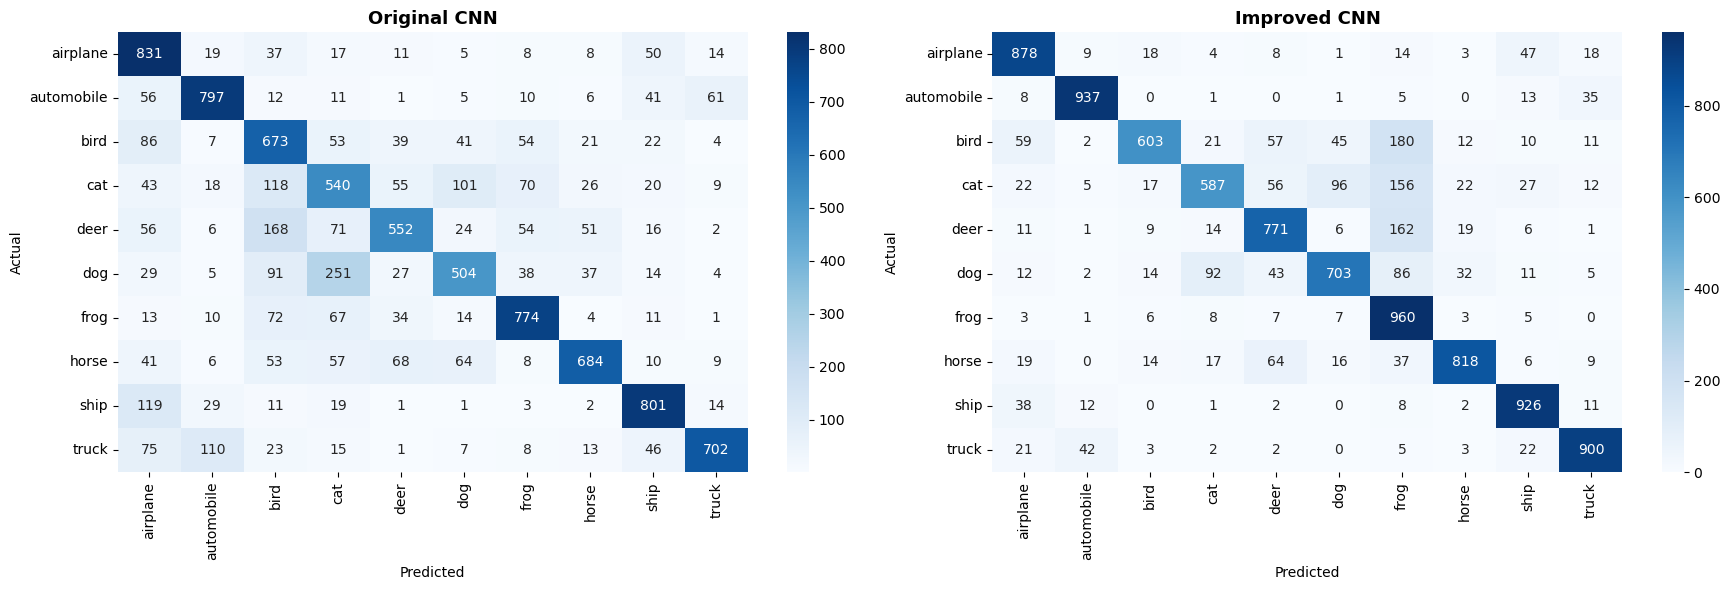

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, preds, title in zip(axes,
                             [cnn_pred_cls, imp_pred_cls],
                             ['Original CNN', 'Improved CNN']):
    cm = confusion_matrix(lbl_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

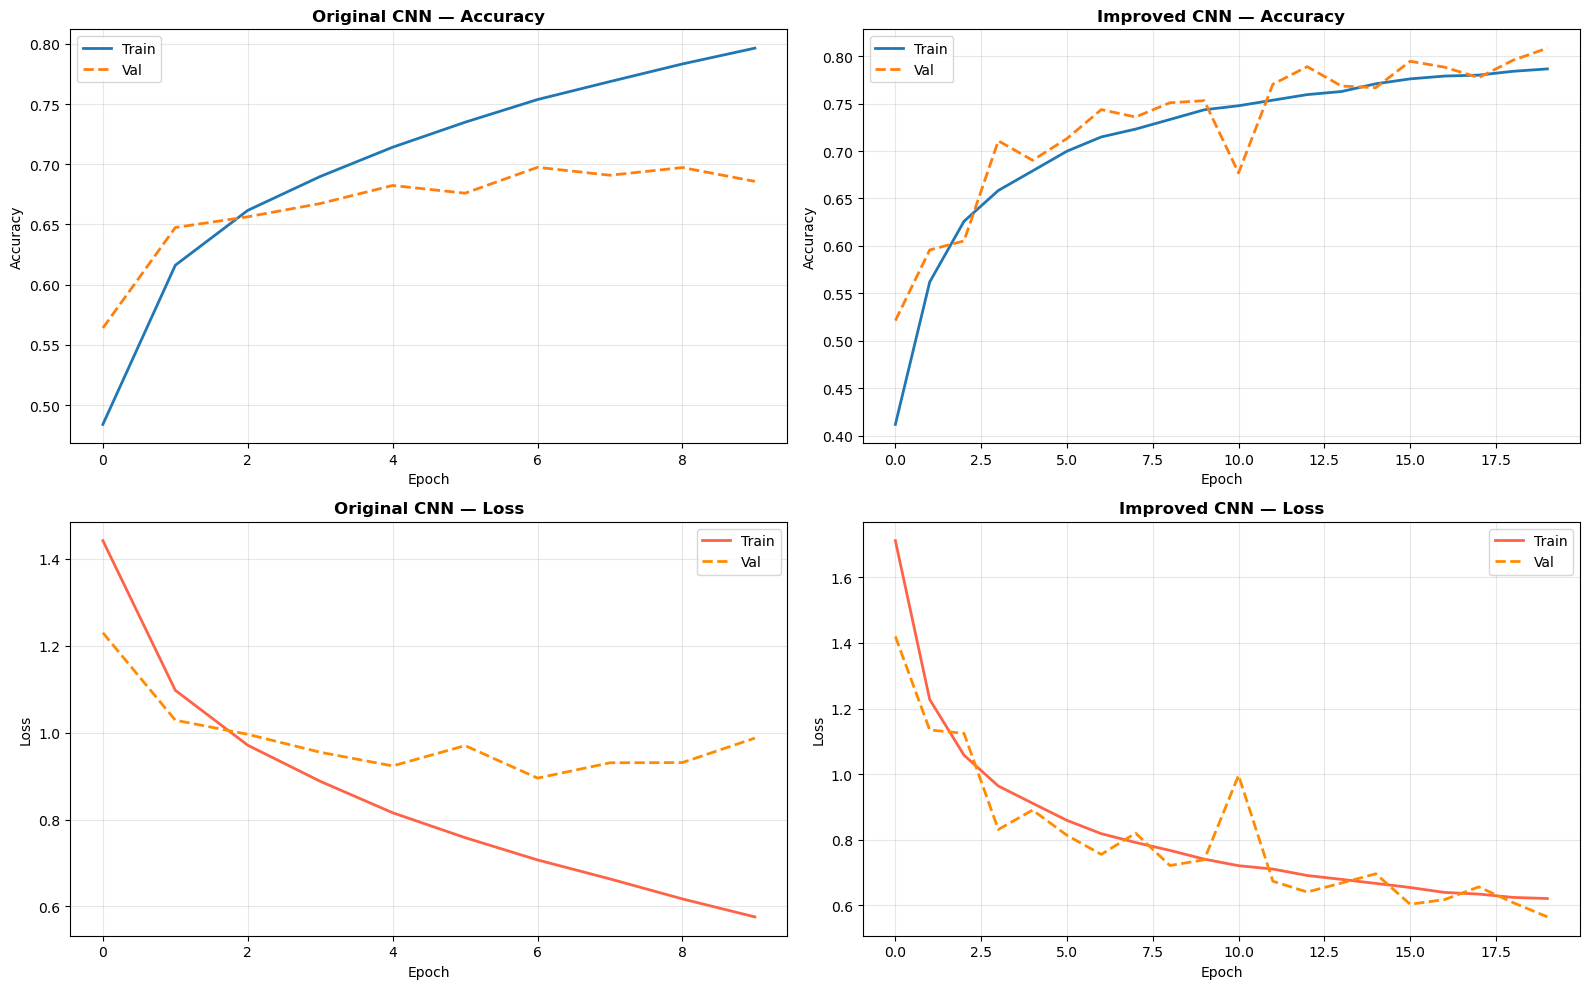

In [44]:
# Training curves — Accuracy & Loss
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (hist, title) in enumerate(zip([cnn_history, improved_history],
                                         ['Original CNN', 'Improved CNN'])):
    axes[0][col].plot(hist.history['accuracy'],     label='Train', linewidth=2)
    axes[0][col].plot(hist.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
    axes[0][col].set_title(f'{title} — Accuracy', fontweight='bold')
    axes[0][col].set_xlabel('Epoch'); axes[0][col].set_ylabel('Accuracy')
    axes[0][col].legend(); axes[0][col].grid(True, alpha=0.3)

    axes[1][col].plot(hist.history['loss'],     label='Train', linewidth=2, color='tomato')
    axes[1][col].plot(hist.history['val_loss'], label='Val',   linewidth=2, linestyle='--', color='darkorange')
    axes[1][col].set_title(f'{title} — Loss', fontweight='bold')
    axes[1][col].set_xlabel('Epoch'); axes[1][col].set_ylabel('Loss')
    axes[1][col].legend(); axes[1][col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
imp_loss, imp_acc = improved_cnn.evaluate(img_test, lbl_test, verbose=0)
print(f"Improved CNN — Accuracy: {imp_acc*100:.2f}% | Loss: {imp_loss:.4f}")

Improved CNN — Accuracy: 80.83% | Loss: 0.5640


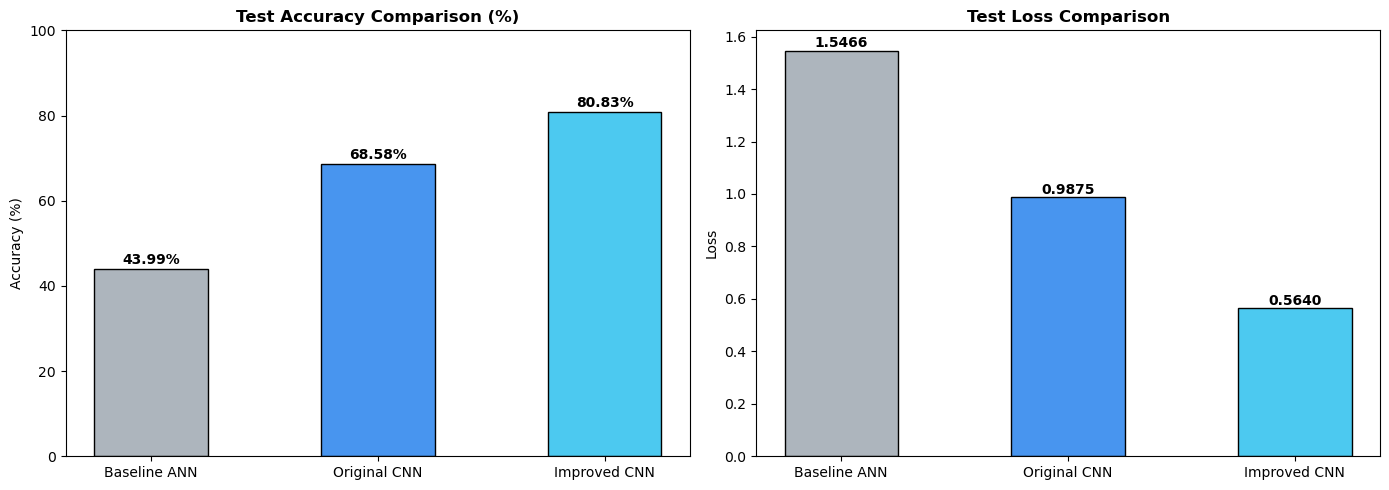

In [49]:
# Summary comparison bar chart
model_names = ['Baseline ANN', 'Original CNN', 'Improved CNN']
acc_vals    = [ann_acc * 100, cnn_acc * 100, imp_acc * 100]
loss_vals   = [ann_loss, cnn_loss, imp_loss]
bar_colours = ['#adb5bd', '#4895ef', '#4cc9f0']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

b1 = axes[0].bar(model_names, acc_vals, color=bar_colours, edgecolor='black', width=0.5)
axes[0].set_title('Test Accuracy Comparison (%)', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(0, 100)
for b, v in zip(b1, acc_vals):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                 f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

b2 = axes[1].bar(model_names, loss_vals, color=bar_colours, edgecolor='black', width=0.5)
axes[1].set_title('Test Loss Comparison', fontweight='bold')
axes[1].set_ylabel('Loss')
for b, v in zip(b2, loss_vals):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.002,
                 f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Sample Predictions — Improved CNN

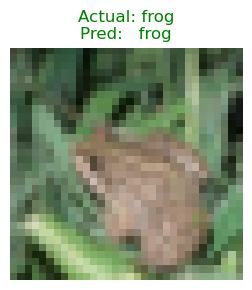

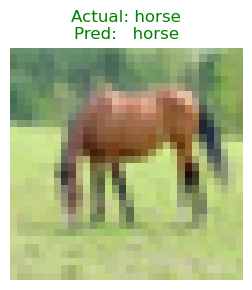

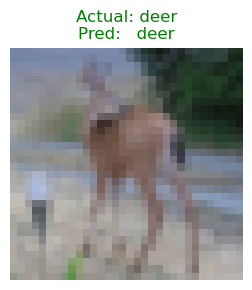

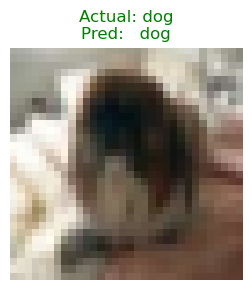

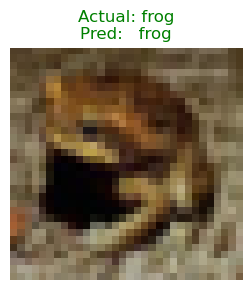

In [52]:
def show_prediction(images, true_labels, pred_labels, idx):
    plt.figure(figsize=(3, 3))
    plt.imshow(images[idx])
    actual = label_names[true_labels[idx]]
    predicted = label_names[pred_labels[idx]]
    colour = 'green' if actual == predicted else 'red'
    plt.title(f'Actual: {actual}\nPred:   {predicted}', color=colour)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

for i in [4, 60, 100, 200, 300]:
    show_prediction(img_test, lbl_test, imp_pred_cls, i)